In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import seaborn as sns
import warnings
import plotly.express as px

warnings.filterwarnings('ignore')

# Loading dataset

In [2]:
data = pd.read_csv('../input/insurance/insurance.csv')

In [3]:
display(data)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


# Data preparation

## Check missing values

In [5]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Check duplicate data

In [6]:
print(f'Checking the duplicate values in given dataset: {data.duplicated().sum()}')

Checking the duplicate values in given dataset: 1


In [7]:
data.drop_duplicates(keep='first', inplace = True, )

In [8]:
print(f'Checking the duplicate values in given dataset: {data.duplicated().sum()}')

Checking the duplicate values in given dataset: 0


# Data analysis and visualization  

In [9]:
def plot_data(data):
    num_col= len(data.columns)
    for i in data.columns:
        plt.figure(figsize=(25,5))
        plt.hist(data[i],edgecolor='black', color='g')
        plt.title(i,fontweight='bold')
        plt.show()

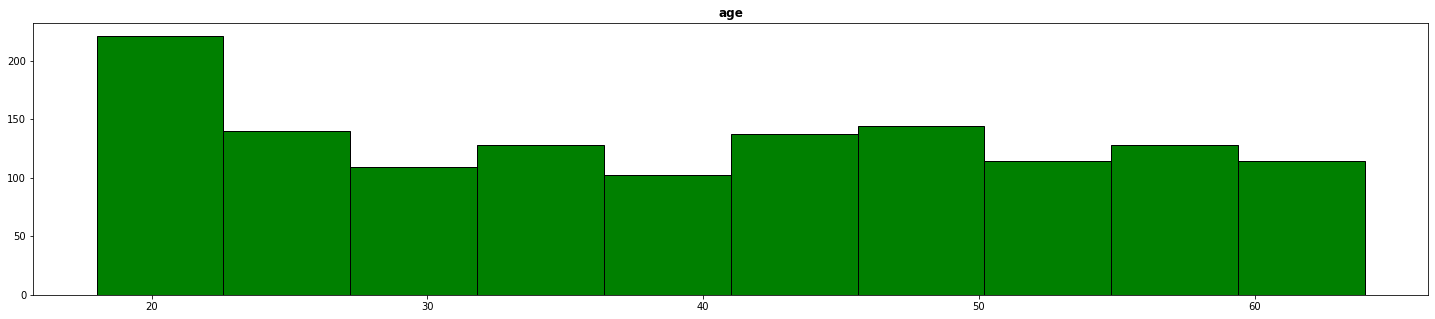

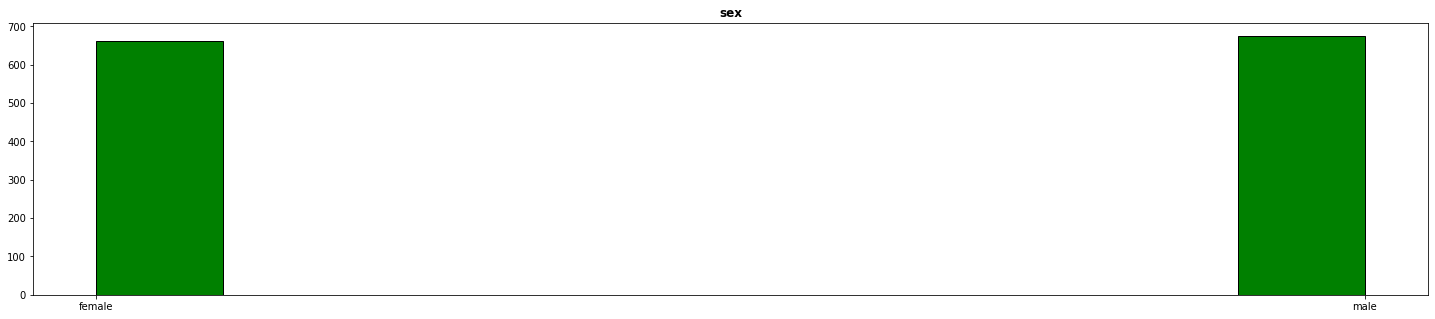

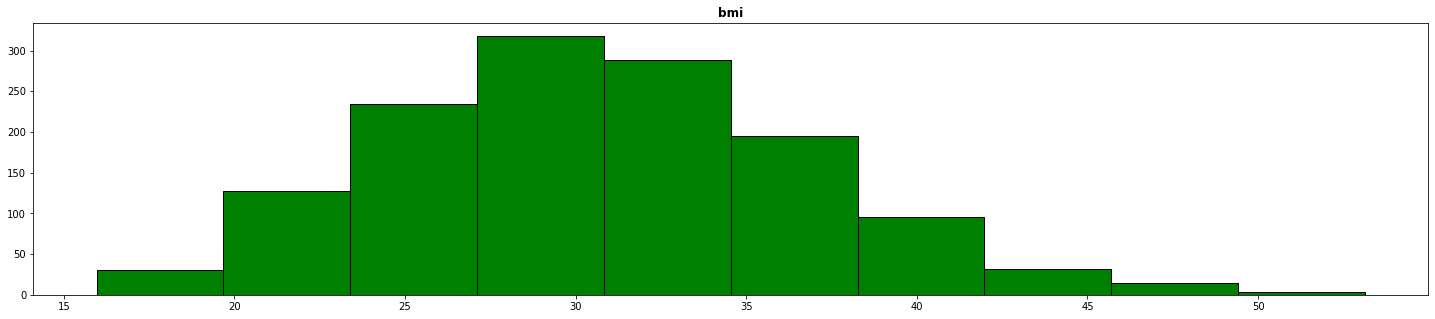

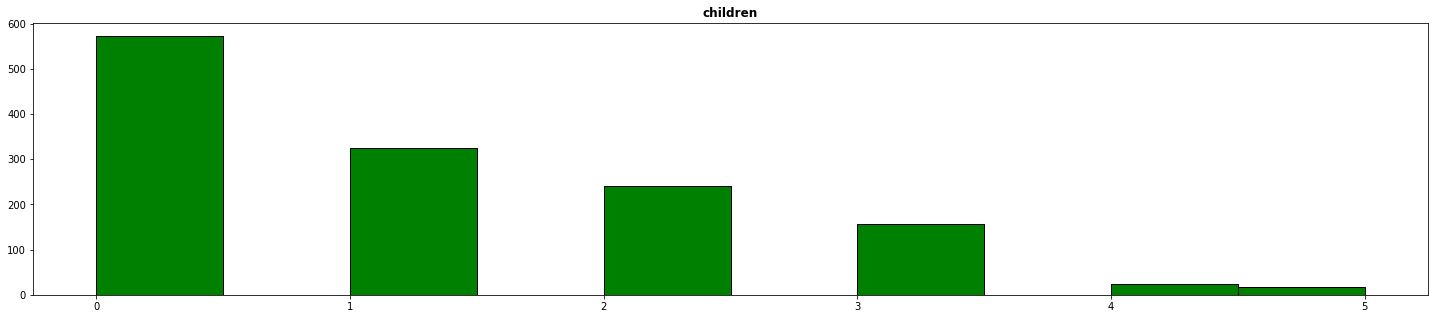

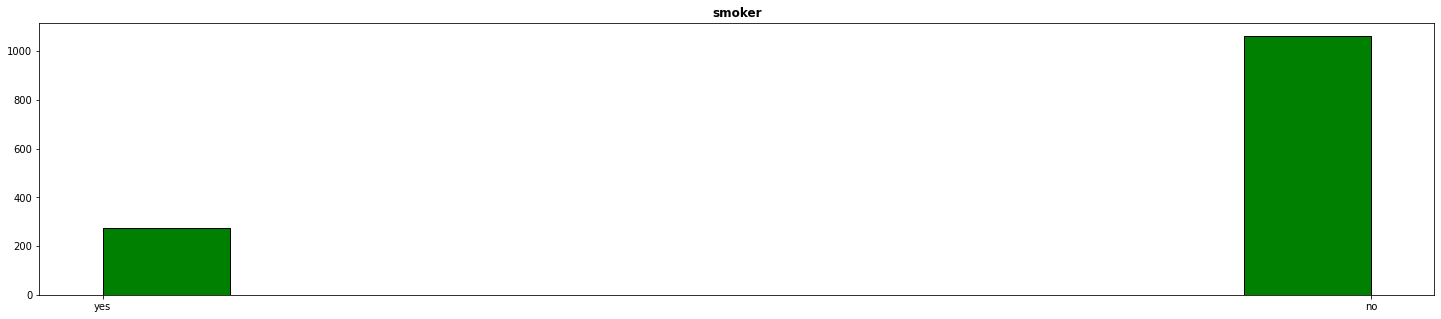

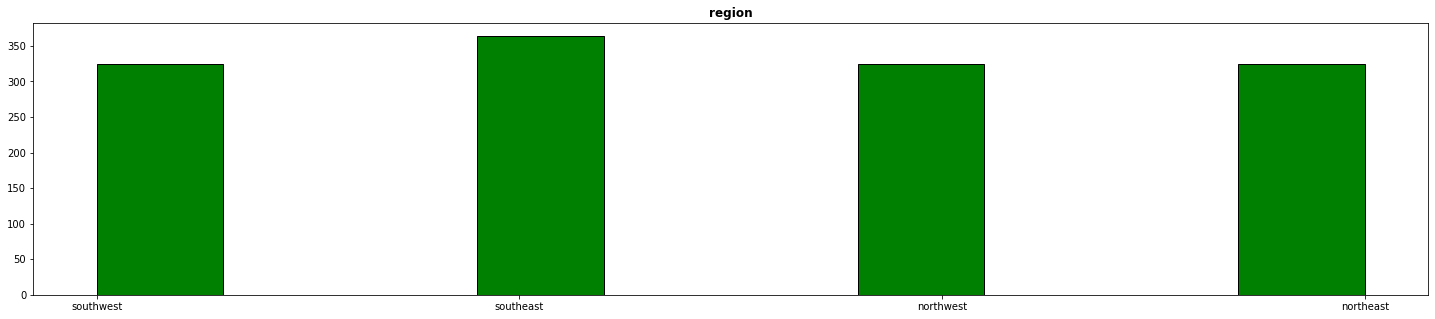

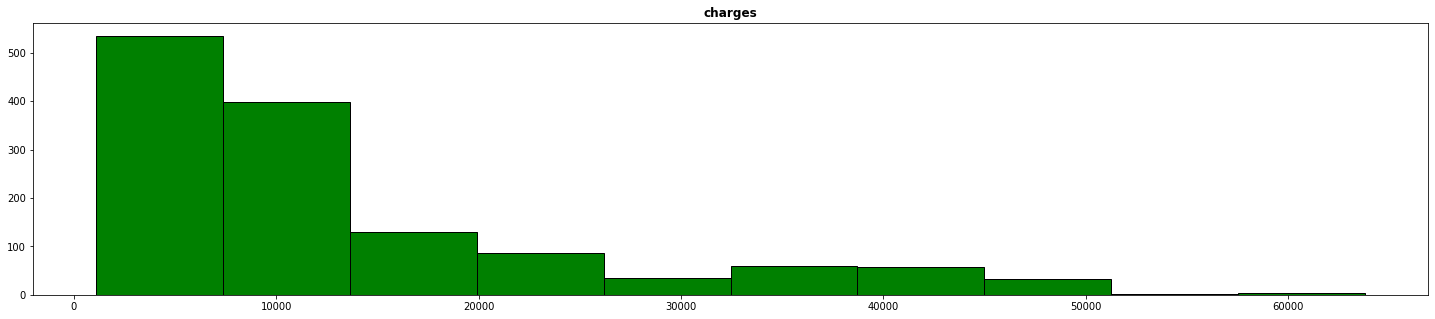

In [10]:
plot_data(data)

Function of ploting both pie chart and bar chart

In [11]:
def plot_df_pie_bar(df,plt_title):
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    plt.pie(df,labels=df.keys(),autopct='%1.2f%%')  
    plt.title(plt_title)

    plt.subplot(1,2,2)
    plt.bar(df.keys(),df)
    plt.show()

## Visualizing age

In [12]:
ages=data['age'].unique()
ages_count=data['age'].value_counts()
print('The age range are from {} to {}.'.format(min(ages),max(ages)))

The age range are from 18 to 64.


<BarContainer object of 47 artists>

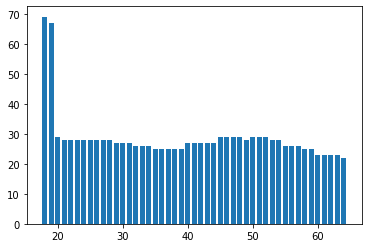

In [13]:
plt.figure(figsize=(6,4))
plt.bar(ages_count.keys(),ages_count)

- The majority of the people we researched in this case were between the ages of 18-20.

## Visualizing gender

In [14]:
sex=data['sex'].unique()
print('the catogories of gender are: {} and {}.'.format(sex[0],sex[1]))
sex_count=data['sex'].value_counts()
print(sex_count)

the catogories of gender are: female and male.
male      675
female    662
Name: sex, dtype: int64


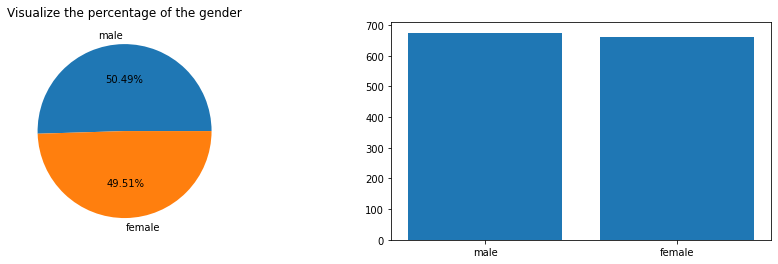

In [15]:
plot_df_pie_bar(sex_count,'Visualize the percentage of the gender')

## Visualizing BMI

In [16]:
bmi=data['bmi'].unique()
bmi.sort()
print('The age range are from {} to {}.'.format(bmi[0],bmi[-1]))

The age range are from 15.96 to 53.13.


- According the standard of BMI Categories.   
Underweight = <18.5  
Normal weight = 18.5–24.9  
Overweight = 25–29.9  
Obesity = BMI of 30 or greater

In [17]:
under_weight=[i for i in data['bmi'] if i<=18.5]
normal_weight=[i for i in data['bmi'] if 18.5<i<25]
over_weight=[i for i in data['bmi'] if 25<=i<30]
obesity=[i for i in data['bmi'] if i>=30]
print('The number of under weight people are:',len(under_weight))
print('The number of normal weight people are:',len(normal_weight))
print('The number of over weight people are:',len(over_weight))
print('The number of obesity weight people are:',len(obesity))

The number of under weight people are: 21
The number of normal weight people are: 224
The number of over weight people are: 386
The number of obesity weight people are: 706


In [18]:
bmi_dic={'under weight':len(under_weight),'normal weight':len(normal_weight),
        'over weight':len(over_weight),'obesity weight':len(obesity)}
bim_df=pd.Series(bmi_dic)

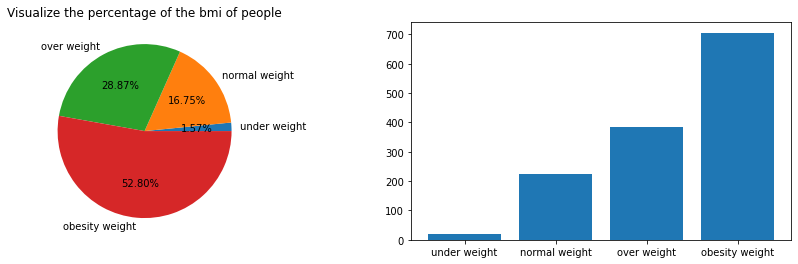

In [19]:
plot_df_pie_bar(bim_df,'Visualize the percentage of the bmi of people')

In [20]:
unhealth=len(under_weight)+len(over_weight)+len(obesity)
health_df=pd.Series({'health':len(normal_weight),'unhealth':unhealth})

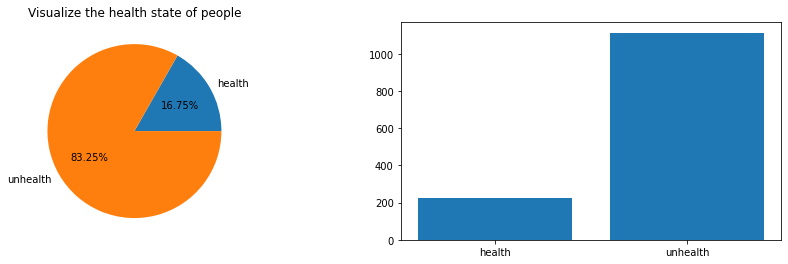

In [21]:
plot_df_pie_bar(health_df,'Visualize the health state of people')

- 83% people has a weight problem.

## Visualizing children

In [22]:
child_num=data['children'].unique()
print('The number of children range are from {} to {}.'.format(min(child_num),max(child_num)))

The number of children range are from 0 to 5.


In [23]:
child_df=pd.Series(data.children.value_counts())

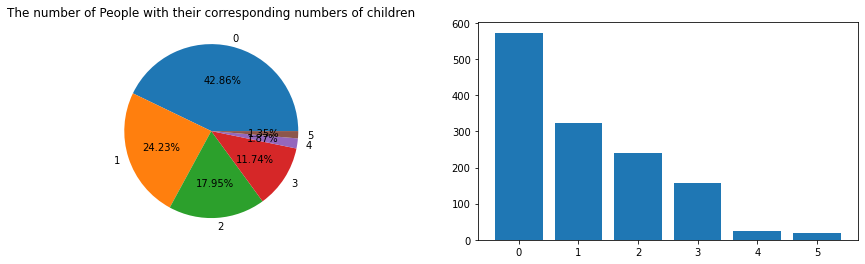

In [24]:
plot_df_pie_bar(child_df,'The number of People with their corresponding numbers of children')

- 57.10% of people have children, and 42.90% do not have any.

## Visualizing smoker

In [25]:
smoker_cate=data['smoker'].unique()
smoker_df=pd.Series(data.smoker.value_counts())
print('The categories of smoker are: {} and {}.'.format(smoker_cate[0],smoker_cate[-1]))
print(smoker_df)

The categories of smoker are: yes and no.
no     1063
yes     274
Name: smoker, dtype: int64


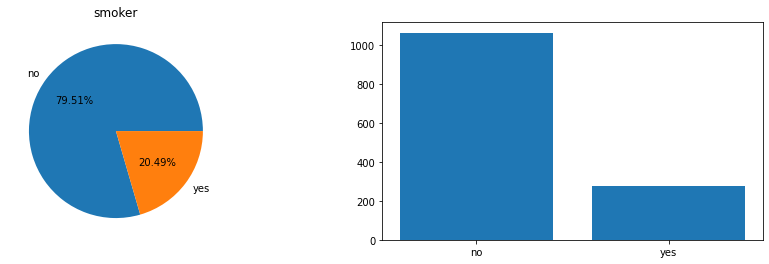

In [26]:
plot_df_pie_bar(smoker_df,'smoker')

- 79.51% of people don't smoke, and 20.49% smoke.

## Visualizing region

In [27]:
region_cate=data['region'].unique()
region_df=pd.Series(data.region.value_counts())
region_df

southeast    364
southwest    325
northwest    324
northeast    324
Name: region, dtype: int64

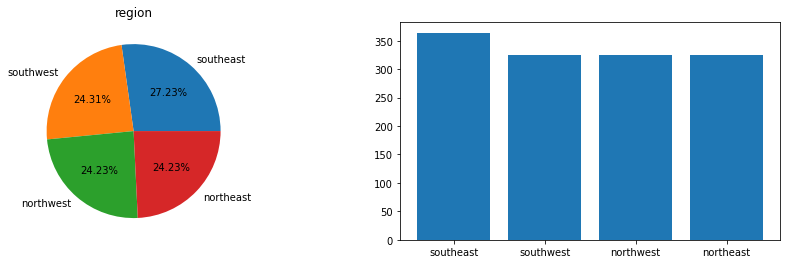

In [28]:
plot_df_pie_bar(region_df,'region')

## Feature selection
- The correlation between the features looks like:

In [29]:
df_all_corr = data.corr().abs().unstack().sort_values(kind="quicksort", ascending=False).reset_index()
df_all_corr.rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: 'Correlation Coefficient'}, inplace=True)
df_all_corr[df_all_corr['Feature 1'] == 'charges']

,Feature 1,Feature 2,Correlation Coefficient
3,charges,charges,1.000000
5,charges,age,0.298308
7,charges,bmi,0.198401
11,charges,children,0.067389


- Smoker is the most important feature we have.

## Visualizing charges

In [30]:
charges=data['charges'].unique()
print('The range of charges are from {} to {}.'.format(round(min(charges),2),round(max(charges),2)))

The range of charges are from 1121.87 to 63770.43.


In [31]:
data['charges'].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

In [32]:
df_no_smoke=data.loc[data['smoker']=='no']
df_smoke=data.loc[data['smoker']=='yes']

<AxesSubplot:xlabel='smoker', ylabel='charges'>

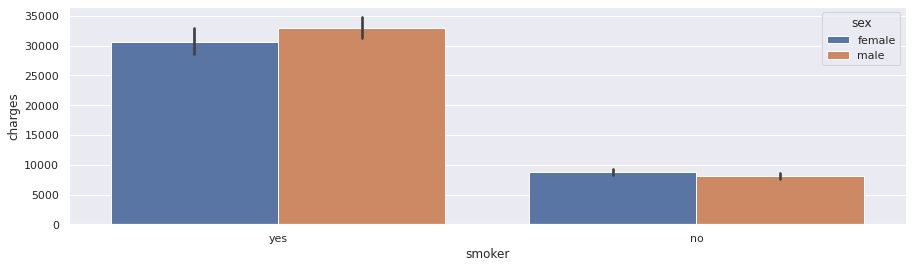

In [33]:
sns.set(rc={'figure.figsize':(15,4)})
sns.barplot('smoker','charges',hue='sex',data=data)

In [34]:
print('The range of charges of people who no smoke are from {} to {}.'.format(round(min(df_no_smoke['charges']),2),round(max(df_no_smoke['charges']),2)))
print('The range of charges of people who smoke are from {} to {}.'.format(round(min(df_smoke['charges']),2),round(max(df_smoke['charges']),2)))
print('The average charge of people who no smoke are {}'.format(round(df_no_smoke['charges'].median(),2)))
print('The average charge of people who smoke are {}'.format(round(df_smoke['charges'].median(),2)))

The range of charges of people who no smoke are from 1121.87 to 36910.61.
The range of charges of people who smoke are from 12829.46 to 63770.43.
The average charge of people who no smoke are 7345.73
The average charge of people who smoke are 34456.35


<AxesSubplot:xlabel='age', ylabel='charges'>

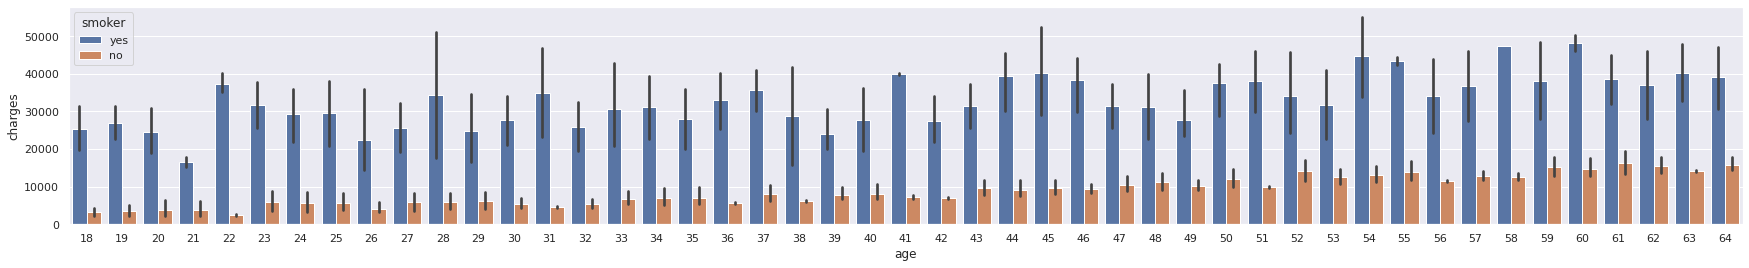

In [35]:
sns.set(rc={'figure.figsize':(30,4)})
sns.barplot('age','charges',hue='smoker',data=data)

- The charges increase as the age increases.  

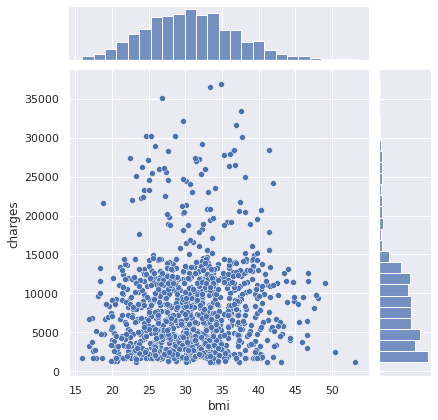

In [36]:
sns.jointplot(x='bmi', y='charges', data=df_no_smoke)

- The BMI won't affect the charges for those who don't smoke

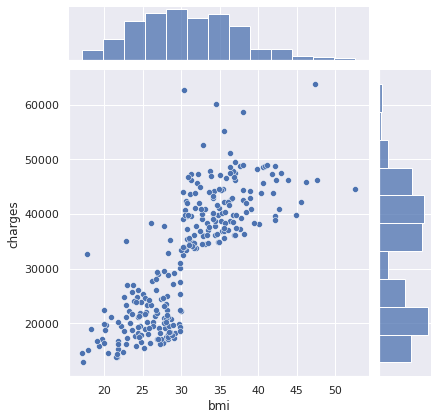

In [37]:
sns.jointplot(x='bmi', y='charges', data=df_smoke)

- The charges increase as the BMI increases for those people who smoke.

# Remove outlier

In [38]:
df_no_smoke=data.loc[data['smoker']=='no']
df_smoke=data.loc[data['smoker']=='yes']

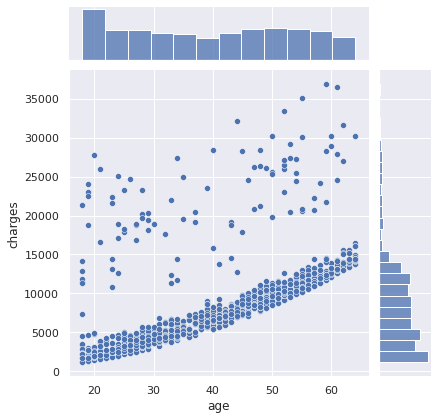

In [39]:
sns.jointplot(x='age', y='charges', data=df_no_smoke)

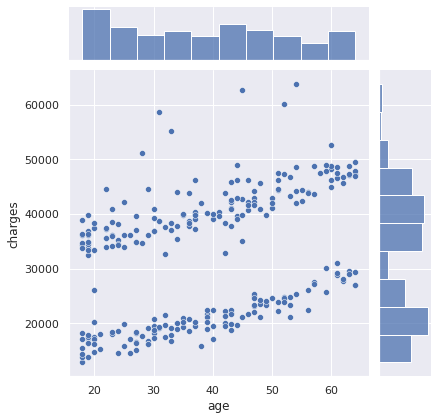

In [40]:
sns.jointplot(x='age', y='charges', data=df_smoke)

- There are so many outlier we can see. Consider only those with costs greater than the oldest person.

In [41]:
odr_no=df_no_smoke.sort_values(by='age',ascending=True)
odr_smoke=df_smoke.sort_values(by=['age','charges'],ascending=True)

In [42]:
drop_smoke_index=data.loc[(data['smoker']=='yes')&(odr_smoke['charges']>50000)].index
drop_no_smoke_index=data.loc[(data['smoker']=='no')&(odr_no['charges']>odr_no['charges'].iloc[-1])].index

In [43]:
data_clean=data.copy()
print('Shape before remove outlier',data.shape)


data_clean=data_clean.drop(drop_no_smoke_index)
data_clean=data_clean.drop(drop_smoke_index)
print('Shape after remove outlier',data_clean.shape)

Shape before remove outlier (1337, 7)
Shape after remove outlier (1249, 7)


## Feature encoding

### Transforming catogiries with LabelEncoder

- We have three categorical columns.Sex, Smoker and the Region.

In [44]:
def categories_lable_to_num(target_data,cate):
    data_encode=target_data.copy()
    d={}
    for cat in cate:
        d[cat]=LabelEncoder().fit(data_encode[cat])
    for cat in cate:
        data_encode[cat] = d[cat].transform(data_encode[cat])
    return data_encode,d

In [45]:
def categories_lable_inverse(target_data,cate,dic):
    data_encode=target_data.copy()
    for cat in cate:
        data_encode[cat] = dic[cat].inverse_transform(data_encode[cat])
    return data_encode

In [46]:
categories = ['sex','smoker','region']
data_encode,dic=categories_lable_to_num(data_clean,categories)

In [47]:
data_encode.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,3,16884.9240
1,18,1,33.77,1,0,2,1725.5523
2,28,1,33.00,3,0,2,4449.4620
4,32,1,28.88,0,0,1,3866.8552
5,31,0,25.74,0,0,2,3756.6216


### Inversing num to categories 

In [48]:
#data_decode=categories_lable_inverse(data_encode,categories,dic)
#data_decode

# Data splitting

### Split target and features

In [49]:
x=data_encode.drop(columns='charges',axis=1)
y=data_encode['charges']

In [50]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(x) # creating an instance of the class object

### Splitting the training set and testing set

In [51]:
x_train,x_test,y_train,y_test= train_test_split(X_scaled,y,test_size=0.15,random_state=42)

In [52]:
print('The shape of x is: ',x.shape)
print('The shape of x_train is: ',x_train.shape)
print('The shape of x_test is: ',x_test.shape)

The shape of x is:  (1249, 6)
The shape of x_train is:  (1061, 6)
The shape of x_test is:  (188, 6)


# Model training and evaluation

In [53]:
reg=LinearRegression()
reg.fit(x_train,y_train)
preds = reg.predict(x_test)
r2_train = metrics.r2_score(y_test,preds)
print("The R squared value of LinearRegression is :", r2_train)

The R squared value of LinearRegression is : 0.8428028143491478


In [54]:
from xgboost import XGBRegressor
xgb_regressor = XGBRegressor()
xgb_regressor.fit(x_train,y_train)
train_data_predx = xgb_regressor.predict(x_test)
score_1 = metrics.r2_score(y_test,train_data_predx)

print("R squared error :",score_1)

R squared error : 0.9541331003391846


In [55]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import accuracy_score
rf_regressor  = RandomForestRegressor()
 
rf_regressor.fit(x_train,y_train)
# make prediction 
preds = rf_regressor.predict(x_test)
# check performance
# R squared value
r2_train = metrics.r2_score(y_test,preds)
print("The R squared value of RandomForestRegressor is :", r2_train)

The R squared value of RandomForestRegressor is : 0.9696599195411999


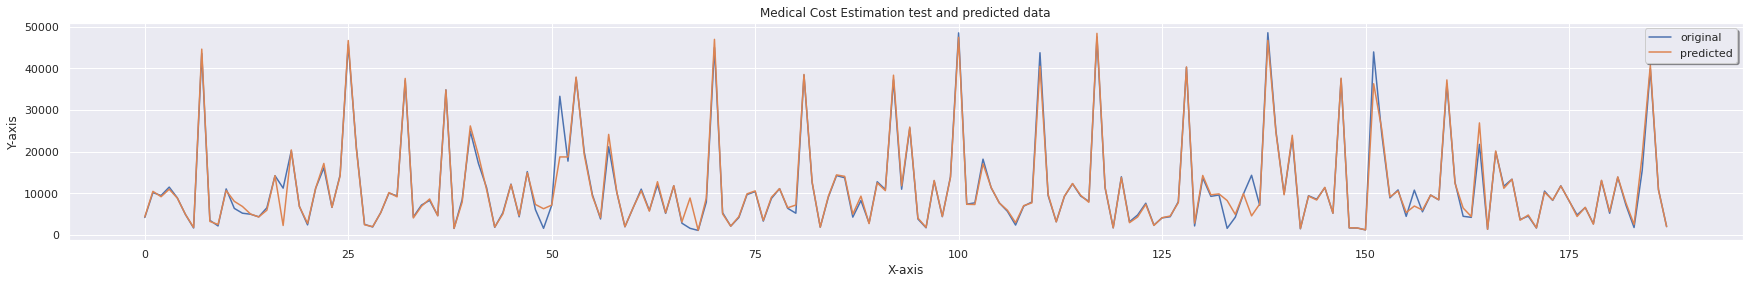

In [56]:
x_ax = range(len(y_test))
plt.plot(x_ax, y_test, label="original")
plt.plot(x_ax, preds, label="predicted")
plt.title("Medical Cost Estimation test and predicted data")
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend(loc='best',fancybox=True, shadow=True)
plt.grid(True)
plt.show()